## Importing dataset

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path = kagglehub.dataset_download('tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset')
print('Data source import complete.')

100%|██████████| 69.5M/69.5M [00:00<00:00, 99.2MB/s]

Extracting files...


Data source import complete.


In [ ]:
tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path

'/root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1'

In [ ]:
dataset_path = tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
# This path MUST match the final output directory from your previous script
AUGMENTED_DIR = f'{dataset_path}/balanced_augmented_dataset'
CLASSES = [
    'Comminuted', 'Greenstick', 'Healthy', 'Oblique Displaced', 'Oblique',
    'Spiral', 'Transverse Displaced', 'Transverse',
]

summary_data = []
total_files = 0

print("=" * 60)
print(f"Inspecting contents of: {AUGMENTED_DIR}")
print("=" * 60)

Inspecting contents of: /root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset


In [ ]:
# Walk through the directory structure: /balanced_augmented_dataset/split/class_name
for split in ['train', 'val', 'test']:
    split_path = os.path.join(AUGMENTED_DIR, split)

    # Check if the split directory exists
    if not os.path.exists(split_path):
        print(f"❌ WARNING: Split directory not found: {split_path}")
        continue

    for cls in CLASSES:
        cls_dir = cls.replace(' ', '_')
        path = os.path.join(split_path, cls_dir)

        count = 0
        if os.path.exists(path):
            count = len(os.listdir(path))
            total_files += count

        summary_data.append({
            'Split': split,
            'Class': cls,
            'Count': count
        })

        # Print a quick check for non-empty folders
        if count > 0:
             print(f"Found {count:5d} files in -> {split}/{cls_dir}")

Found   296 files in -> train/Comminuted
Found   232 files in -> train/Greenstick
Found   176 files in -> train/Healthy
Found   296 files in -> train/Oblique_Displaced
Found   156 files in -> train/Oblique
Found   204 files in -> train/Spiral
Found   296 files in -> train/Transverse_Displaced
Found   296 files in -> train/Transverse
Found    16 files in -> val/Comminuted
Found    12 files in -> val/Greenstick
Found    10 files in -> val/Healthy
Found    16 files in -> val/Oblique_Displaced
Found     9 files in -> val/Oblique
Found    11 files in -> val/Spiral
Found    16 files in -> val/Transverse_Displaced
Found    16 files in -> val/Transverse
Found    17 files in -> test/Comminuted
Found    13 files in -> test/Greenstick
Found    10 files in -> test/Healthy
Found    17 files in -> test/Oblique_Displaced
Found     9 files in -> test/Oblique
Found    12 files in -> test/Spiral
Found    17 files in -> test/Transverse_Displaced
Found    17 files in -> test/Transverse


In [ ]:
# ============================================
# FINAL SUMMARY TABLE
# ============================================

df_summary = pd.DataFrame(summary_data)
summary_pivot = df_summary.pivot(index='Class', columns='Split', values='Count')

print("\n" + "=" * 60)
print("📊 FINAL AUGMENTED DATASET DISTRIBUTION")
print(f"Total files processed: {total_files}")
print("=" * 60)
print(summary_pivot.to_string())
print("=" * 60)


📊 FINAL AUGMENTED DATASET DISTRIBUTION
Total files processed: 2170
Split                 test  train  val
Class                                 
Comminuted              17    296   16
Greenstick              13    232   12
Healthy                 10    176   10
Oblique                  9    156    9
Oblique Displaced       17    296   16
Spiral                  12    204   11
Transverse              17    296   16
Transverse Displaced    17    296   16


## Dataset Analysis

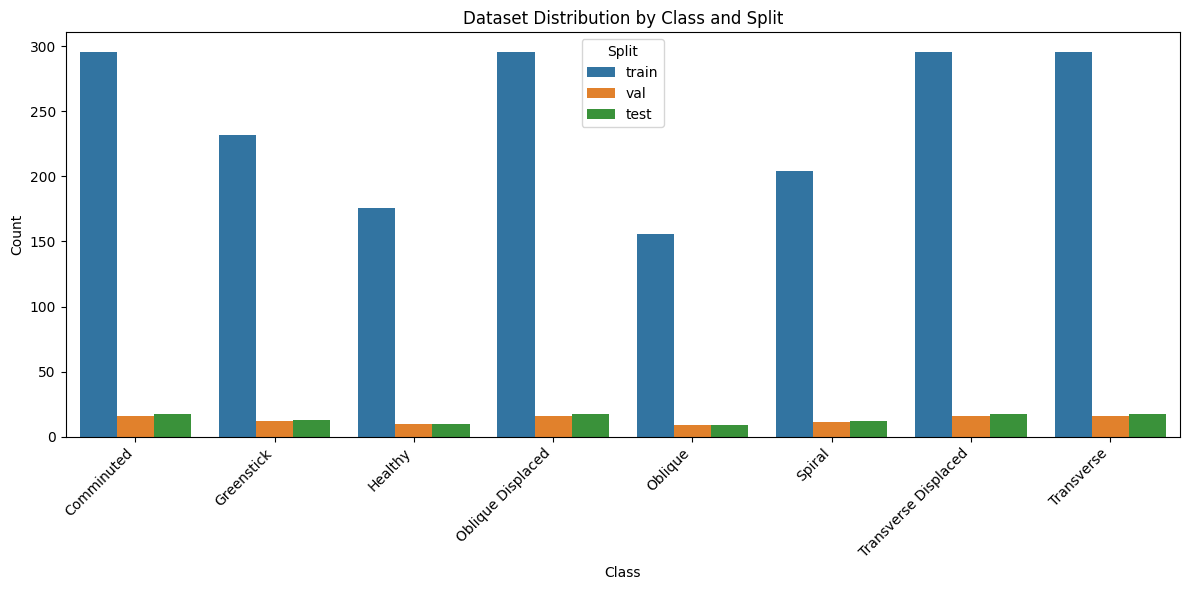

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of classes across splits
plt.figure(figsize=(12, 6))
sns.barplot(data=df_summary, x='Class', y='Count', hue='Split')
plt.title('Dataset Distribution by Class and Split')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
split_totals = df_summary.groupby('Split')['Count'].sum()
df_summary['Percentage'] = df_summary.apply(
    lambda row: (row['Count'] / split_totals[row['Split']]) * 100 if split_totals[row['Split']] > 0 else 0,
    axis=1
)

percentage_pivot = df_summary.pivot(index='Class', columns='Split', values='Percentage')

print("\n" + "=" * 60)
print("📊 CLASS DISTRIBUTION PERCENTAGES PER SPLIT")
print("=" * 60)
print(percentage_pivot.to_string(float_format='%.2f'))
print("=" * 60)


📊 CLASS DISTRIBUTION PERCENTAGES PER SPLIT
Split                 test  train   val
Class                                  
Comminuted           15.18  15.16 15.09
Greenstick           11.61  11.89 11.32
Healthy               8.93   9.02  9.43
Oblique               8.04   7.99  8.49
Oblique Displaced    15.18  15.16 15.09
Spiral               10.71  10.45 10.38
Transverse           15.18  15.16 15.09
Transverse Displaced 15.18  15.16 15.09


In [ ]:
from PIL import Image

image_dimensions = []

print("\n" + "=" * 60)
print("Analyzing image dimensions...")
print("=" * 60)

for split in ['train', 'val', 'test']:
    split_path = os.path.join(AUGMENTED_DIR, split)

    if not os.path.exists(split_path):
        print(f"❌ WARNING: Split directory not found: {split_path}")
        continue

    for cls in CLASSES:
        print(f"Processing class: {cls}")
        cls_dir = cls.replace(' ', '_')
        path = os.path.join(split_path, cls_dir)
        # print(path)
        if os.path.exists(path):
            for img_file in os.listdir(path):
                img_path = os.path.join(path, img_file)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        image_dimensions.append({'Split': split, 'Class': cls, 'Width': width, 'Height': height})
                except Exception as e:
                    print(f"Error opening image {img_path}: {e}")

print("Finished analyzing image dimensions.")


Analyzing image dimensions...
Processing class: Comminuted
Processing class: Greenstick
Processing class: Healthy
Processing class: Oblique Displaced
Processing class: Oblique
Processing class: Spiral
Processing class: Transverse Displaced
Processing class: Transverse
Processing class: Comminuted
Processing class: Greenstick
Processing class: Healthy
Processing class: Oblique Displaced
Processing class: Oblique
Processing class: Spiral
Processing class: Transverse Displaced
Processing class: Transverse
Processing class: Comminuted
Processing class: Greenstick
Processing class: Healthy
Processing class: Oblique Displaced
Processing class: Oblique
Processing class: Spiral
Processing class: Transverse Displaced
Processing class: Transverse
Finished analyzing image dimensions.


In [ ]:
df_dimensions = pd.DataFrame(image_dimensions)

print("\n" + "=" * 60)
print("📊 IMAGE DIMENSIONS ANALYSIS")
print("=" * 60)
display(df_dimensions.describe())
print("=" * 60)


📊 IMAGE DIMENSIONS ANALYSIS


,Width,Height
count,2170.0,2170.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0



🖼️ DISPLAYING SAMPLE IMAGES


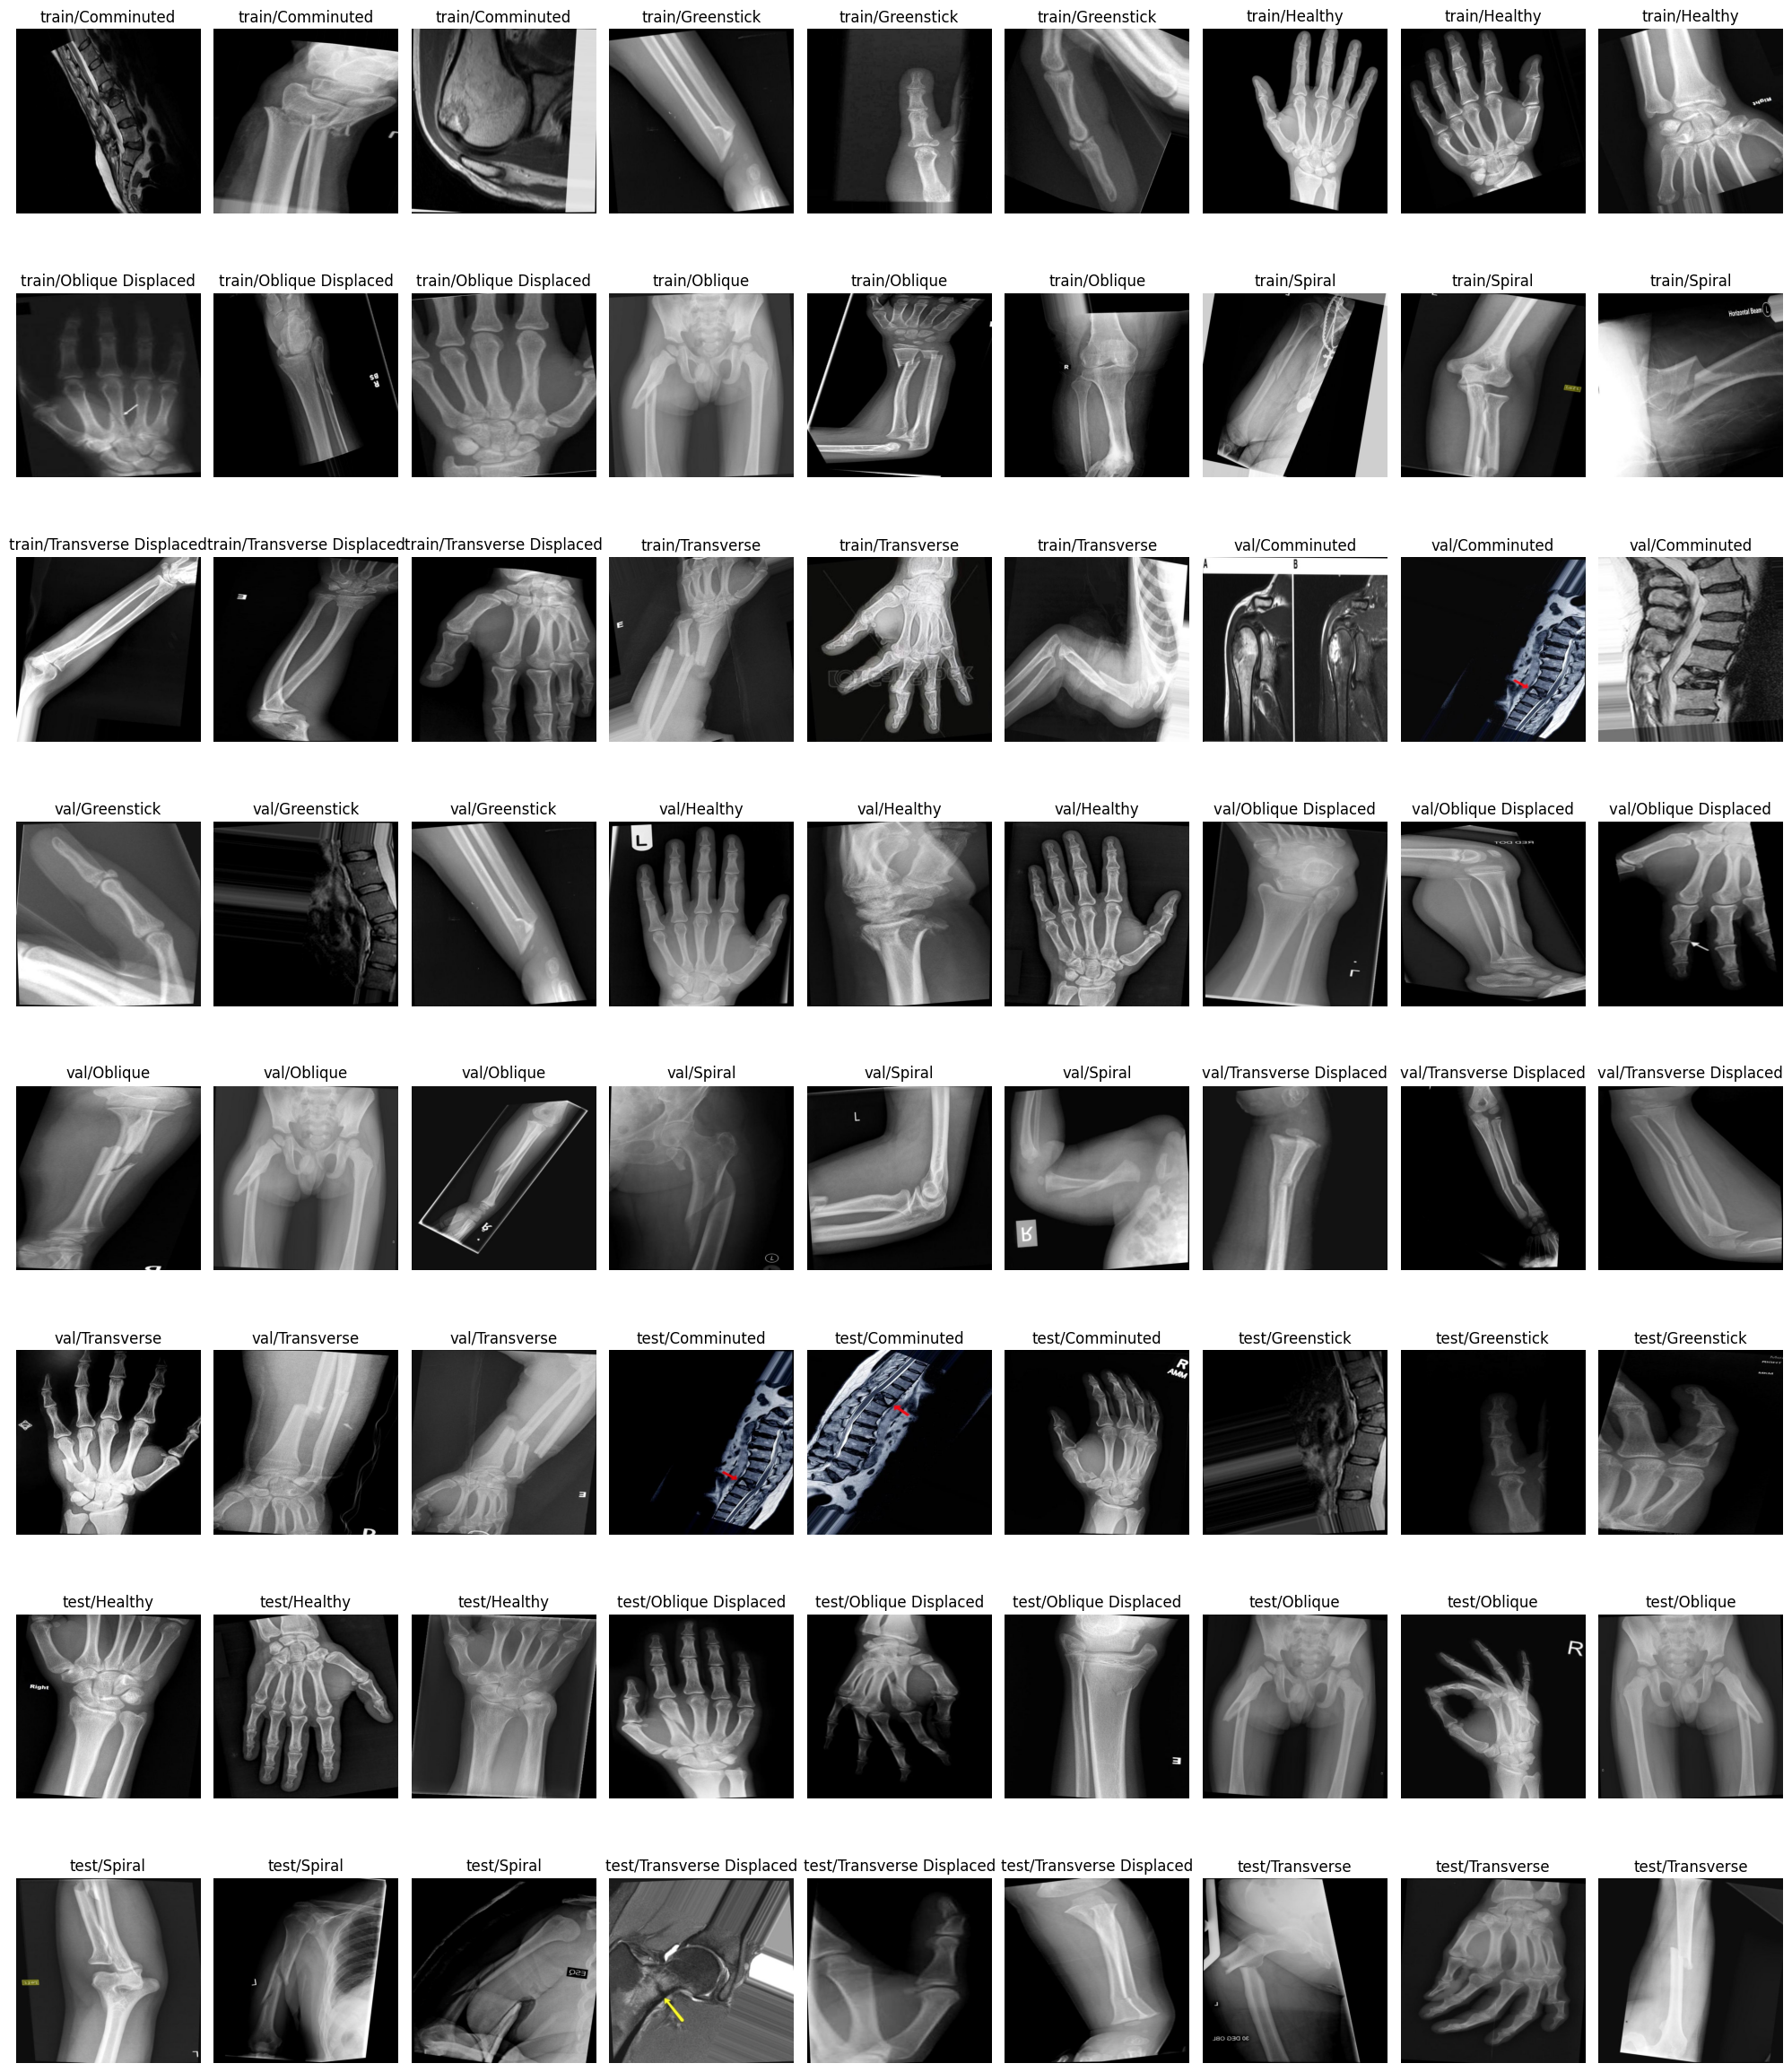

Finished displaying sample images.


In [ ]:
import random

print("\n" + "=" * 60)
print("🖼️ DISPLAYING SAMPLE IMAGES")
print("=" * 60)

# Define number of samples to display per class per split
NUM_SAMPLES = 3
fig, axes = plt.subplots(nrows=len(CLASSES), ncols=NUM_SAMPLES * len(['train', 'val', 'test']), figsize=(20, len(CLASSES) * 3))
axes = axes.flatten()
img_idx = 0

for split in ['train', 'val', 'test']:
    split_path = os.path.join(AUGMENTED_DIR, split)

    if not os.path.exists(split_path):
        print(f"❌ WARNING: Split directory not found for displaying samples: {split_path}")
        continue

    for cls in CLASSES:
        cls_dir = cls.replace(' ', '_')
        path = os.path.join(split_path, cls_dir)

        if os.path.exists(path):
            image_files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if image_files:
                sample_images = random.sample(image_files, min(len(image_files), NUM_SAMPLES))

                for img_path in sample_images:
                    try:
                        with Image.open(img_path) as img:
                            axes[img_idx].imshow(img)
                            axes[img_idx].set_title(f"{split}/{cls}")
                            axes[img_idx].axis('off')
                            img_idx += 1
                    except Exception as e:
                        print(f"Error opening image {img_path} for display: {e}")
            else:
                print(f"No image files found in {split}/{cls_dir} for displaying samples.")
        else:
             print(f"Class directory not found for displaying samples: {split}/{cls_dir}")


# Hide any unused subplots
for i in range(img_idx, len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

print("Finished displaying sample images.")

In [ ]:
data = []
for split in ['train', 'val', 'test']:
    split_path = os.path.join(AUGMENTED_DIR, split)
    if not os.path.exists(split_path):
        print(f"❌ WARNING: Split directory not found: {split_path}")
        continue

    for i, cls in enumerate(CLASSES):
        cls_dir = cls.replace(' ', '_')
        class_path = os.path.join(split_path, cls_dir)
        if os.path.exists(class_path):
            for img_file in os.listdir(class_path):
                # You can choose to use absolute or relative paths here.
                # For this example, let's use absolute paths.
                image_path = os.path.join(class_path, img_file)
                data.append({'image_path': image_path, 'label': i}) # Use index as label

# Create a DataFrame
df_dataset = pd.DataFrame(data)

# Save to CSV files
for split in ['train', 'val', 'test']:
    df_split = df_dataset[df_dataset['image_path'].str.contains(f'/{split}/')]
    csv_path = f'{split}.csv'
    df_split.to_csv(csv_path, index=False)
    print(f"Generated {csv_path} with {len(df_split)} entries.")

Generated train.csv with 1952 entries.
Generated val.csv with 106 entries.
Generated test.csv with 112 entries.


In [ ]:
source_dir = '/content/'
destination_dir = '/root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset'

# List of CSV files to move
csv_files = ['train.csv', 'val.csv', 'test.csv']

# Move each file
for file_name in csv_files:
    source_path = os.path.join(source_dir, file_name)
    destination_path = os.path.join(destination_dir, file_name)

    # Check if the source file exists before attempting to move
    if os.path.exists(source_path):
        try:
            os.rename(source_path, destination_path)
            print(f"Moved {file_name} to {destination_dir}")
        except OSError as e:
            print(f"Error moving {file_name}: {e}")
    else:
        print(f"Source file not found: {source_path}")

Moved train.csv to /root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset
Moved val.csv to /root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset
Moved test.csv to /root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset


In [ ]:
import shutil
from google.colab import files

folder_path = '/root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset'
zip_path = '/content/balanced_augmented_dataset.zip'

# Create a zip archive of the folder
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Training

In [ ]:
!pip install -q --upgrade pip
!pip install -q torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -q timm scikit-learn opencv-python matplotlib wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00


In [ ]:
import os
import time
from pathlib import Path
import numpy as np
from PIL import Image
import csv

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tvmodels
import timm

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import wandb

In [ ]:
def detect_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = detect_device()
print('Using device:', DEVICE)

Using device: cuda


In [ ]:
DATA_DIR = f'{dataset_path}/balanced_augmented_dataset'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
VAL_CSV = os.path.join(DATA_DIR, 'val.csv')
TEST_CSV = os.path.join(DATA_DIR, 'test.csv')

CONFIG = {
    'model': 'convnext',         # options: 'swin','convnext','densenet'
    'num_classes': 8,
    'img_size': 224,
    'batch_size': 12,        # for T4: 12-16 works for small models
    'epochs': 18,
    'lr': 1e-4,
    'weight_decay': 1e-2,
    'out_dir': '/content/outputs',
    'project': 'fracture-classification',
    'entity': None           # set your wandb username or org if desired
}

os.makedirs(CONFIG['out_dir'], exist_ok=True)

In [ ]:
def load_csv_like(path: str):
    rows = []
    with open(path, 'r') as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    return rows

class FractureDataset(Dataset):
    def __init__(self, rows, img_root='.', transform=None):
        self.rows = rows
        self.img_root = img_root
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        p = r['image_path']
        if not os.path.isabs(p):
            p = os.path.join(self.img_root, p)
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(r['label'])
        return img, label

# %%
# 6) Transforms

def get_transforms(split='train', img_size=224):
    if split=='train':
        return T.Compose([
            T.Resize((int(img_size*1.05), int(img_size*1.05))),
            T.RandomResizedCrop(img_size, scale=(0.8,1.0)),
            T.RandomRotation(15),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    return T.Compose([
        T.Resize((img_size,img_size)),
        T.CenterCrop(img_size),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

# %%
# 7) Model factory

def get_model(name, num_classes, pretrained=True):
    name = name.lower()
    if name.startswith('swin'):
        m = timm.create_model('swin_small_patch4_window7_224', pretrained=pretrained)
        m.head = nn.Linear(m.head.in_features, num_classes)
        return m
    if name.startswith('convnext'):
        m = timm.create_model('convnext_tiny', pretrained=pretrained)
        m.head.fc = nn.Linear(m.head.fc.in_features, num_classes)
        return m
    if name.startswith('densenet'):
        m = tvmodels.densenet169(pretrained=pretrained)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        return m
    raise ValueError('unknown model')

# %%
# 8) Training & validation loops (with wandb logging)

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    running_loss = 0.0
    preds, targs = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        autocast = torch.cuda.amp.autocast if device.type=='cuda' else torch.autocast
        with autocast():
            out = model(imgs)
            # Ensure output is (batch_size, num_classes)
            if out.ndim > 2:
                out = out.view(out.size(0), out.size(1), -1).mean(-1)

            # Add assertion to check labels
            assert torch.all(labels >= 0) and torch.all(labels < model.module.num_classes if isinstance(model, nn.DataParallel) else labels < model.head.out_features), f"Labels out of expected range: {labels}"

            loss = criterion(out, labels)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds.extend(out.softmax(dim=1).argmax(dim=1).detach().cpu().numpy().tolist())
        targs.extend(labels.detach().cpu().numpy().tolist())
    loss = running_loss / len(loader.dataset)
    p,r,f1,_ = precision_recall_fscore_support(targs, preds, average='macro', zero_division=0)
    return loss, p,r,f1


def validate(model, loader, criterion, device):
    model.eval(); running_loss=0.0; preds=[]; targs=[]
    with torch.no_grad():
        autocast = torch.cuda.amp.autocast if device.type=='cuda' else torch.autocast
        with autocast():
            for imgs, labels in loader:
                imgs = imgs.to(device); labels = labels.to(device)
                out = model(imgs)
                # Ensure output is (batch_size, num_classes)
                if out.ndim > 2:
                    out = out.view(out.size(0), out.size(1), -1).mean(-1)

                # Add assertion to check labels
                assert torch.all(labels >= 0) and torch.all(labels < model.module.num_classes if isinstance(model, nn.DataParallel) else labels < model.head.out_features), f"Labels out of expected range: {labels}"

                loss = criterion(out, labels)
                running_loss += loss.item() * imgs.size(0)
                preds.extend(out.softmax(dim=1).argmax(dim=1).cpu().numpy().tolist())
                targs.extend(labels.cpu().numpy().tolist())
    loss = running_loss / len(loader.dataset)
    p,r,f1,_ = precision_recall_fscore_support(targs, preds, average='macro', zero_division=0)
    cm = confusion_matrix(targs, preds)
    return loss,p,r,f1,cm

In [ ]:
!wandb login

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tirath-bhathawala (mumbaihacks) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
train_rows = load_csv_like(TRAIN_CSV)
val_rows = load_csv_like(VAL_CSV)
test_rows = load_csv_like(TEST_CSV)

In [ ]:
train_ds = FractureDataset(train_rows, img_root=DATA_DIR, transform=get_transforms('train', CONFIG['img_size']))
val_ds = FractureDataset(val_rows, img_root=DATA_DIR, transform=get_transforms('val', CONFIG['img_size']))

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=(DEVICE.type=='cuda'))
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=(DEVICE.type=='cuda'))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
try:
    model = get_model(CONFIG['model'], CONFIG['num_classes'], pretrained=True)

    # Add diagnostic prints
    print("\n--- Model Structure Before Transfer ---")
    print(model)
    print("---------------------------------------")

    # Inspect the final layer's expected input features
    if CONFIG['model'].lower().startswith('swin'):
        print(f"Swin Transformer head input features: {model.head.in_features}")
    elif CONFIG['model'].lower().startswith('convnext'):
         print(f"ConvNeXt head input features: {model.head.fc.in_features}")
    elif CONFIG['model'].lower().startswith('densenet'):
         print(f"DenseNet classifier input features: {model.classifier.in_features}")
    print(f"Configured number of classes: {CONFIG['num_classes']}")
    print("---------------------------------------")

    model.to(DEVICE)
    print(f"\nModel successfully moved to {DEVICE}")

except Exception as e:
    print(f"Error during model initialization or transfer to device: {e}")


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
if DEVICE.type=='cuda':
    scaler = torch.cuda.amp.GradScaler()
else:
    scaler = None

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


--- Model Structure Before Transfer ---
ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), s

/tmp/ipython-input-133077856.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
wandb.init(project=CONFIG['project'], entity=CONFIG['entity'], config=CONFIG)
best_f1 = 0.0
for epoch in range(CONFIG['epochs']):
    t0 = time.time()
    train_loss, train_p, train_r, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_loss, val_p, val_r, val_f1, cm = validate(model, val_loader, criterion, DEVICE)
    elapsed = time.time()-t0
    print(f"Epoch {epoch}/{CONFIG['epochs']} time={elapsed:.1f}s train_f1={train_f1:.4f} val_f1={val_f1:.4f}")
    # log to wandb
    wandb.log({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'train_f1': train_f1, 'val_f1': val_f1})
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch, 'val_f1': val_f1}, os.path.join(CONFIG['out_dir'], 'best.pth'))
wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
best_path = os.path.join(CONFIG['out_dir'], 'best.pth')
if os.path.exists(best_path):
    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck['model_state_dict'])
    print('Loaded best checkpoint from', best_path)

In [ ]:
from torch.utils.data import DataLoader

test_ds = FractureDataset(test_rows, img_root=DATA_DIR, transform=get_transforms('val', CONFIG['img_size']))
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=(DEVICE.type=='cuda'))

test_loss, test_p, test_r, test_f1, test_cm = validate(model, test_loader, criterion, DEVICE)
print('Test macro-F1:', test_f1)
np.savetxt(os.path.join(CONFIG['out_dir'], 'confusion_matrix.txt'), test_cm, fmt='%d')